In [50]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yfinance as yf
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler

try:
    from hmmlearn.hmm import GaussianHMM
except ImportError:
    GaussianHMM = None

warnings.filterwarnings("ignore", category=FutureWarning)
plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 140)

TRADING_DAYS = 252
DATA_PERIOD = "20y"
FWD_HORIZONS = [5, 22]

TICKERS = {
    "SPX": "^GSPC",
    "VIX": "^VIX",
    "VIX9D": "^VIX9D",
    "VVIX": "^VVIX",
    "SKEW": "^SKEW",
    "SDEX": "^SDEX",
}

## Methodology Overview

The research treats volatility regime detection as an empirical classification problem. Rather than assuming a regime label in advance, the notebook builds features that describe volatility, trend, drawdown, and choppiness, then compares multiple two-state classifiers.

The goal is not just to find a model that splits the data into two groups. The useful model is the one whose low-vol state behaves like a slow-bull environment and whose high-vol state behaves like a choppy risk environment.

In [51]:
def download_close(ticker: str, period: str = DATA_PERIOD) -> pd.Series:
    """Download a single adjusted close series from Yahoo Finance."""
    raw = yf.download(ticker, period=period, auto_adjust=True, progress=False)
    if raw.empty or "Close" not in raw:
        print(f"Warning: no close data returned for {ticker}")
        return pd.Series(dtype="float64", name=ticker)

    close = raw["Close"]
    if isinstance(close, pd.DataFrame):
        close = close.iloc[:, 0]
    close.name = ticker
    return close.astype(float)


prices = pd.concat({name: download_close(ticker) for name, ticker in TICKERS.items()}, axis=1)
prices = prices.sort_index()
prices.tail()

,SPX,VIX,VIX9D,VVIX,SKEW,SDEX
Date,,,,,,
2026-06-12,7431.459961,17.680000,17.26,93.820000,142.600006,58.060001
2026-06-15,7554.290039,16.200001,NaN,87.580002,144.320007,59.070000
2026-06-16,7511.350098,16.410000,NaN,87.690002,142.660004,60.230000
2026-06-17,7420.100098,18.440001,NaN,94.529999,142.619995,61.790001
2026-06-18,7500.580078,16.400000,NaN,88.430000,146.720001,60.430000


## Data Collection

The study uses daily SPX and volatility-index data from Yahoo Finance. SPX provides the price path and realized returns, while VIX-family and risk-sentiment indices provide implied-volatility context.

Some Yahoo tickers may have shorter histories or occasional missing values, so the notebook builds the study sample only after the required SPX, VIX, realized-volatility, trend, drawdown, and choppiness features are available.

In [52]:
def build_features(prices: pd.DataFrame) -> pd.DataFrame:
    df = prices.copy()
    df["SPX_ret"] = np.log(df["SPX"] / df["SPX"].shift(1))

    # Annualized realized volatility in percent, comparable to VIX levels.
    df["RV_21"] = df["SPX_ret"].rolling(21).std() * np.sqrt(TRADING_DAYS) * 100
    df["RV_63"] = df["SPX_ret"].rolling(63).std() * np.sqrt(TRADING_DAYS) * 100
    df["VRP_21"] = df["VIX"] - df["RV_21"]
    df["lagged_VRP_21"] = df["VIX"].shift(21) - df["RV_21"]

    df["trend_63"] = df["SPX"].pct_change(63)
    df["trend_126"] = df["SPX"].pct_change(126)
    df["ma_50"] = df["SPX"].rolling(50).mean()
    df["ma_200"] = df["SPX"].rolling(200).mean()
    df["ma_gap_50_200"] = df["ma_50"] / df["ma_200"] - 1

    rolling_peak = df["SPX"].rolling(252, min_periods=63).max()
    df["drawdown_252"] = df["SPX"] / rolling_peak - 1

    ret_sign = np.sign(df["SPX_ret"])
    df["sign_flip_21"] = ret_sign.ne(ret_sign.shift(1)).rolling(21).mean()
    df["abs_ret_21"] = df["SPX_ret"].abs().rolling(21).mean() * TRADING_DAYS * 100

    if "VIX9D" in df:
        df["vix9d_vix"] = df["VIX9D"] / df["VIX"]
    if "VVIX" in df:
        df["vvix_vix"] = df["VVIX"] / df["VIX"]
    if {"SKEW", "SDEX"}.issubset(df.columns):
        df["skew_sdex"] = df["SKEW"] / df["SDEX"]

    for horizon in FWD_HORIZONS:
        df[f"fwd_ret_{horizon}d"] = df["SPX"].shift(-horizon) / df["SPX"] - 1

    return df


df = build_features(prices)
model_features = [
    "VIX",
    "RV_21",
    "RV_63",
    "VRP_21",
    "vix9d_vix",
    "vvix_vix",
    "trend_63",
    "ma_gap_50_200",
    "drawdown_252",
    "sign_flip_21",
]
model_features = [col for col in model_features if col in df.columns]
study_df = df.dropna(subset=["SPX", "SPX_ret", "VIX", "RV_21", "RV_63", "trend_63", "drawdown_252", "sign_flip_21"]).copy()

print(f"Study sample: {study_df.index.min().date()} to {study_df.index.max().date()} ({len(study_df):,} rows)")
study_df[model_features + ["SPX_ret", "fwd_ret_5d", "fwd_ret_22d"]].tail()

Study sample: 2006-09-18 to 2026-05-22 (4,951 rows)


,VIX,RV_21,RV_63,VRP_21,vix9d_vix,vvix_vix,trend_63,ma_gap_50_200,drawdown_252,sign_flip_21,SPX_ret,fwd_ret_5d,fwd_ret_22d
Date,,,,,,,,,,,,,
2026-05-18,17.820000,10.846789,14.674881,6.973211,0.946128,5.116723,0.081808,0.021985,-0.013090,0.619048,-0.000736,NaN,0.002303
2026-05-19,18.059999,11.156363,14.733331,6.903636,0.921373,5.238649,0.068635,0.022788,-0.019681,0.571429,-0.006701,0.022507,0.019986
2026-05-20,17.440001,11.188318,14.837438,6.251683,0.868119,5.530390,0.083225,0.023875,-0.009101,0.619048,0.010734,0.011757,NaN
2026-05-21,16.760000,10.805663,14.793380,5.954337,0.840095,5.482100,0.077605,0.024982,-0.007401,0.571429,0.001714,0.015836,NaN
2026-05-22,16.700001,10.582586,14.611010,6.117415,0.842515,5.458683,0.092972,0.026485,-0.003702,0.523810,0.003720,0.014262,NaN


## Feature Engineering

The core problem is to describe both volatility level and price behavior. VIX is already annualized in percent terms, so realized volatility is converted to the same unit before computing volatility risk premium features.

The notebook also adds trend, moving-average distance, drawdown, and return sign-flip features. The sign-flip measure is a simple proxy for choppiness: a market that changes direction frequently over the last month should look different from a steady slow-bull advance.

In [53]:
def label_high_low(data: pd.DataFrame, raw_labels: pd.Series, method_name: str) -> pd.Series:
    """Map arbitrary two-state labels to low_vol/high_vol using realized vol and choppiness."""
    aligned = data.loc[raw_labels.index].copy()
    score = (
        aligned["RV_21"].groupby(raw_labels).mean().rank()
        + aligned["sign_flip_21"].groupby(raw_labels).mean().rank()
        - aligned["trend_63"].groupby(raw_labels).mean().rank()
    )
    high_label = score.idxmax()
    return pd.Series(np.where(raw_labels.eq(high_label), "high_vol", "low_vol"), index=raw_labels.index, name=method_name)


def threshold_regime(data: pd.DataFrame, high_q: float = 0.70, low_q: float = 0.55) -> pd.Series:
    """Percentile threshold with hysteresis: high-vol turns on above high_q and off below low_q."""
    score = 0.55 * data["RV_21"].rank(pct=True) + 0.30 * data["VIX"].rank(pct=True) + 0.15 * data["sign_flip_21"].rank(pct=True)
    regimes = []
    current = "low_vol"
    for value in score:
        if current == "low_vol" and value >= high_q:
            current = "high_vol"
        elif current == "high_vol" and value <= low_q:
            current = "low_vol"
        regimes.append(current)
    return pd.Series(regimes, index=data.index, name="threshold")


def clustering_regime(data: pd.DataFrame, features: list[str]) -> pd.Series:
    cluster_data = data[features].replace([np.inf, -np.inf], np.nan).dropna()
    X = StandardScaler().fit_transform(cluster_data)
    model = GaussianMixture(n_components=2, covariance_type="full", random_state=42, n_init=10)
    labels = pd.Series(model.fit_predict(X), index=cluster_data.index)
    return label_high_low(data.loc[cluster_data.index], labels, "cluster")


def hmm_regime(data: pd.DataFrame, features: list[str], train_window: int = 756, refit_step: int = 21) -> pd.Series:
    if GaussianHMM is None:
        print("hmmlearn is not installed; skipping HMM regime.")
        return pd.Series(index=data.index, dtype="object", name="hmm")

    hmm_data = data[features].replace([np.inf, -np.inf], np.nan).dropna()
    if len(hmm_data) <= train_window:
        print("Not enough observations for walk-forward HMM.")
        return pd.Series(index=hmm_data.index, dtype="object", name="hmm")

    regimes = pd.Series(index=hmm_data.index, dtype="object", name="hmm")
    diagnostics = []

    for train_end in range(train_window, len(hmm_data), refit_step):
        train_start = train_end - train_window
        test_end = min(train_end + refit_step, len(hmm_data))
        train_idx = hmm_data.index[train_start:train_end]
        test_idx = hmm_data.index[train_end:test_end]
        train_X = hmm_data.iloc[train_start:train_end]
        test_X = hmm_data.iloc[train_end:test_end]

        scaler = StandardScaler()
        X_train = scaler.fit_transform(train_X)
        X_test = scaler.transform(test_X)

        best_model = None
        best_score = -np.inf
        for seed in [7, 21, 42, 101]:
            model = GaussianHMM(
                n_components=2,
                covariance_type="diag",
                n_iter=500,
                min_covar=1e-3,
                random_state=seed,
            )
            try:
                model.fit(X_train)
                score = model.score(X_train)
                if np.isfinite(score) and score > best_score:
                    best_model = model
                    best_score = score
            except Exception:
                continue

        if best_model is None:
            diagnostics.append({"train_end": train_idx[-1], "status": "failed_fit"})
            continue

        try:
            train_states = pd.Series(best_model.predict(X_train), index=train_idx)
            test_states = pd.Series(best_model.predict(X_test), index=test_idx)
        except Exception as exc:
            diagnostics.append({"train_end": train_idx[-1], "status": f"failed_decode: {exc}"})
            continue

        mapped_train = label_high_low(data.loc[train_idx], train_states, "hmm_train")
        high_state = train_states[mapped_train.eq("high_vol")].mode()
        high_state = high_state.iloc[0] if not high_state.empty else train_states.mode().iloc[0]
        regimes.loc[test_idx] = np.where(test_states.eq(high_state), "high_vol", "low_vol")
        diagnostics.append({"train_end": train_idx[-1], "test_end": test_idx[-1], "status": "ok", "score": best_score})

    hmm_regime.diagnostics_ = pd.DataFrame(diagnostics)
    return regimes.dropna()


cluster_features = [col for col in ["VIX", "RV_21", "RV_63", "VRP_21", "trend_63", "ma_gap_50_200", "drawdown_252", "sign_flip_21"] if col in study_df]
hmm_features = [col for col in ["VIX", "RV_21", "RV_63", "trend_63", "drawdown_252", "sign_flip_21"] if col in study_df]

regimes = pd.DataFrame(index=study_df.index)
regimes["threshold"] = threshold_regime(study_df)
regimes["cluster"] = clustering_regime(study_df, cluster_features)
regimes["hmm"] = hmm_regime(study_df, hmm_features)

for col in regimes:
    study_df[f"regime_{col}"] = regimes[col]

regimes.apply(lambda s: s.value_counts(dropna=False)).T

,high_vol,low_vol,NaN
threshold,1730.0,3221.0,NaN
cluster,1580.0,3235.0,136.0
hmm,1351.0,2844.0,756.0


## Regime Detection Methods

This section compares three ways to identify the two regimes.

The threshold method is the most transparent baseline. It uses realized volatility, VIX, and return sign changes, with hysteresis to avoid noisy day-to-day flips.

The clustering method lets the data group similar volatility, trend, drawdown, and choppiness environments. Since cluster labels are arbitrary, the notebook maps the higher-volatility and higher-choppiness cluster to `high_vol`.

The HMM method adds regime persistence by estimating latent states through time. It is useful as a benchmark, but it can be fragile, so the notebook uses longer rolling windows, periodic refits, multiple random seeds, and regularized covariance settings.

In [54]:
def max_drawdown(returns: pd.Series) -> float:
    wealth = (1 + returns.dropna()).cumprod()
    if wealth.empty:
        return np.nan
    return (wealth / wealth.cummax() - 1).min()


def average_duration(regime: pd.Series, target: str) -> float:
    clean = regime.dropna()
    if clean.empty:
        return np.nan
    blocks = clean.ne(clean.shift()).cumsum()
    durations = clean.groupby(blocks).agg(["first", "size"])
    selected = durations.loc[durations["first"].eq(target), "size"]
    return selected.mean() if not selected.empty else np.nan


def evaluate_regime_method(data: pd.DataFrame, regime: pd.Series, method: str) -> pd.DataFrame:
    eval_df = data.join(regime.rename("regime"), how="inner").dropna(subset=["regime", "SPX_ret"])
    rows = []
    transitions = int(eval_df["regime"].ne(eval_df["regime"].shift()).sum() - 1) if len(eval_df) else 0
    years = len(eval_df) / TRADING_DAYS if len(eval_df) else np.nan

    for label, group in eval_df.groupby("regime"):
        daily = group["SPX_ret"].dropna()
        simple_daily = np.exp(daily) - 1
        compounded = (1 + simple_daily).prod()
        ann_return = compounded ** (TRADING_DAYS / len(simple_daily)) - 1 if len(simple_daily) else np.nan

        rows.append(
            {
                "method": method,
                "regime": label,
                "observations": len(group),
                "share": len(group) / len(eval_df),
                "avg_duration_days": average_duration(eval_df["regime"], label),
                "transitions_per_year": transitions / years if years and years > 0 else np.nan,
                "ann_return": ann_return,
                "ann_vol": simple_daily.std() * np.sqrt(TRADING_DAYS),
                "max_drawdown": max_drawdown(simple_daily),
                "daily_hit_rate": (simple_daily > 0).mean(),
                "avg_RV_21": group["RV_21"].mean(),
                "avg_VIX": group["VIX"].mean(),
                "avg_trend_63": group["trend_63"].mean(),
                "avg_drawdown_252": group["drawdown_252"].mean(),
                "avg_sign_flip_21": group["sign_flip_21"].mean(),
                "mean_fwd_5d": group["fwd_ret_5d"].mean(),
                "mean_fwd_22d": group["fwd_ret_22d"].mean(),
            }
        )
    return pd.DataFrame(rows)


summary = pd.concat(
    [evaluate_regime_method(study_df, regimes[col], col) for col in regimes.columns],
    ignore_index=True,
)

summary.sort_values(["method", "regime"]).style.format(
    {
        "share": "{:.1%}",
        "avg_duration_days": "{:.1f}",
        "transitions_per_year": "{:.1f}",
        "ann_return": "{:.1%}",
        "ann_vol": "{:.1%}",
        "max_drawdown": "{:.1%}",
        "daily_hit_rate": "{:.1%}",
        "avg_RV_21": "{:.1f}",
        "avg_VIX": "{:.1f}",
        "avg_trend_63": "{:.1%}",
        "avg_drawdown_252": "{:.1%}",
        "avg_sign_flip_21": "{:.1%}",
        "mean_fwd_5d": "{:.2%}",
        "mean_fwd_22d": "{:.2%}",
    }
)

,method,regime,observations,share,avg_duration_days,transitions_per_year,ann_return,ann_vol,max_drawdown,daily_hit_rate,avg_RV_21,avg_VIX,avg_trend_63,avg_drawdown_252,avg_sign_flip_21,mean_fwd_5d,mean_fwd_22d
2,cluster,high_vol,1580,32.8%,27.7,6.0,-7.9%,29.7%,-55.4%,51.8%,25.7,27.4,-2.1%,-14.7%,52.9%,0.33%,1.30%
3,cluster,low_vol,3235,67.2%,55.8,6.0,18.3%,12.4%,-11.2%,55.8%,11.9,16.2,4.6%,-1.7%,51.6%,0.14%,0.66%
4,hmm,high_vol,1351,32.2%,13.6,11.9,1.1%,24.4%,-34.8%,51.7%,21.2,22.8,-0.7%,-8.2%,51.3%,0.34%,1.43%
5,hmm,low_vol,2844,67.8%,28.4,11.9,18.2%,12.5%,-16.1%,56.2%,11.7,16.5,5.1%,-1.9%,51.2%,0.22%,0.98%
0,threshold,high_vol,1730,34.9%,69.2,2.5,2.4%,29.2%,-56.7%,53.1%,26.4,27.4,-2.1%,-13.5%,54.7%,0.28%,1.20%
1,threshold,low_vol,3221,65.1%,123.9,2.5,13.1%,11.6%,-12.3%,55.4%,10.8,15.5,4.9%,-1.7%,50.4%,0.17%,0.72%


## Regime Evaluation

Each model produces a two-state label, but the label is only useful if the resulting regimes behave differently in economically meaningful ways.

The evaluation below checks whether the supposed low-vol regime actually looks like a slow bull: lower volatility, stronger trend, shallower drawdowns, and fewer return sign changes. It also checks whether the high-vol regime is genuinely choppy: higher volatility, more direction changes, weaker forward returns, and worse drawdowns.

In [55]:
def regime_spreads(summary: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for method, group in summary.groupby("method"):
        pivot = group.set_index("regime")
        if {"low_vol", "high_vol"}.issubset(pivot.index):
            rows.append(
                {
                    "method": method,
                    "rv_spread_high_minus_low": pivot.loc["high_vol", "avg_RV_21"] - pivot.loc["low_vol", "avg_RV_21"],
                    "vix_spread_high_minus_low": pivot.loc["high_vol", "avg_VIX"] - pivot.loc["low_vol", "avg_VIX"],
                    "flip_spread_high_minus_low": pivot.loc["high_vol", "avg_sign_flip_21"] - pivot.loc["low_vol", "avg_sign_flip_21"],
                    "trend_spread_low_minus_high": pivot.loc["low_vol", "avg_trend_63"] - pivot.loc["high_vol", "avg_trend_63"],
                    "drawdown_spread_high_minus_low": pivot.loc["high_vol", "avg_drawdown_252"] - pivot.loc["low_vol", "avg_drawdown_252"],
                    "transition_rate": pivot["transitions_per_year"].mean(),
                    "horizon_22d_spread_low_minus_high": pivot.loc["low_vol", "mean_fwd_22d"] - pivot.loc["high_vol", "mean_fwd_22d"],
                }
            )
    return pd.DataFrame(rows).set_index("method")


spreads = regime_spreads(summary)
spreads.style.format(
    {
        "rv_spread_high_minus_low": "{:.1f}",
        "vix_spread_high_minus_low": "{:.1f}",
        "flip_spread_high_minus_low": "{:.1%}",
        "trend_spread_low_minus_high": "{:.1%}",
        "drawdown_spread_high_minus_low": "{:.1%}",
        "transition_rate": "{:.1f}",
        "horizon_22d_spread_low_minus_high": "{:.2%}",
    }
)

,rv_spread_high_minus_low,vix_spread_high_minus_low,flip_spread_high_minus_low,trend_spread_low_minus_high,drawdown_spread_high_minus_low,transition_rate,horizon_22d_spread_low_minus_high
method,,,,,,,
cluster,13.8,11.2,1.4%,6.7%,-13.0%,6.0,-0.64%
hmm,9.4,6.3,0.2%,5.8%,-6.3%,11.9,-0.44%
threshold,15.6,11.9,4.4%,7.0%,-11.8%,2.5,-0.49%


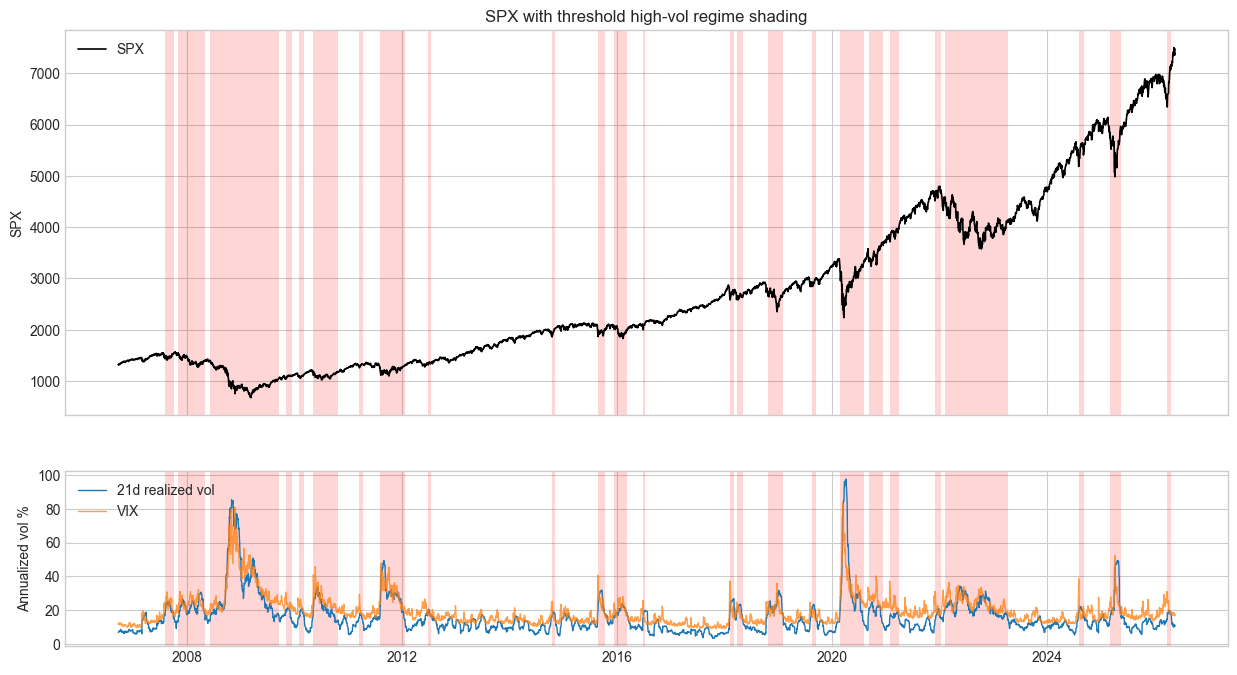

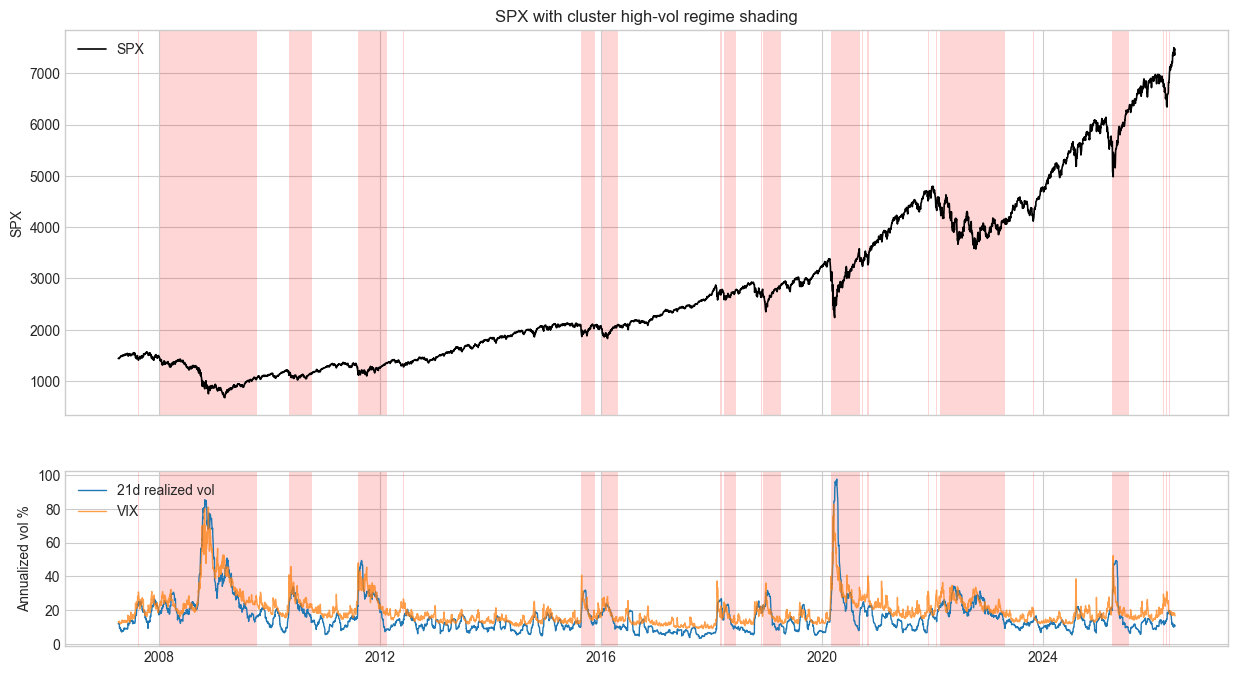

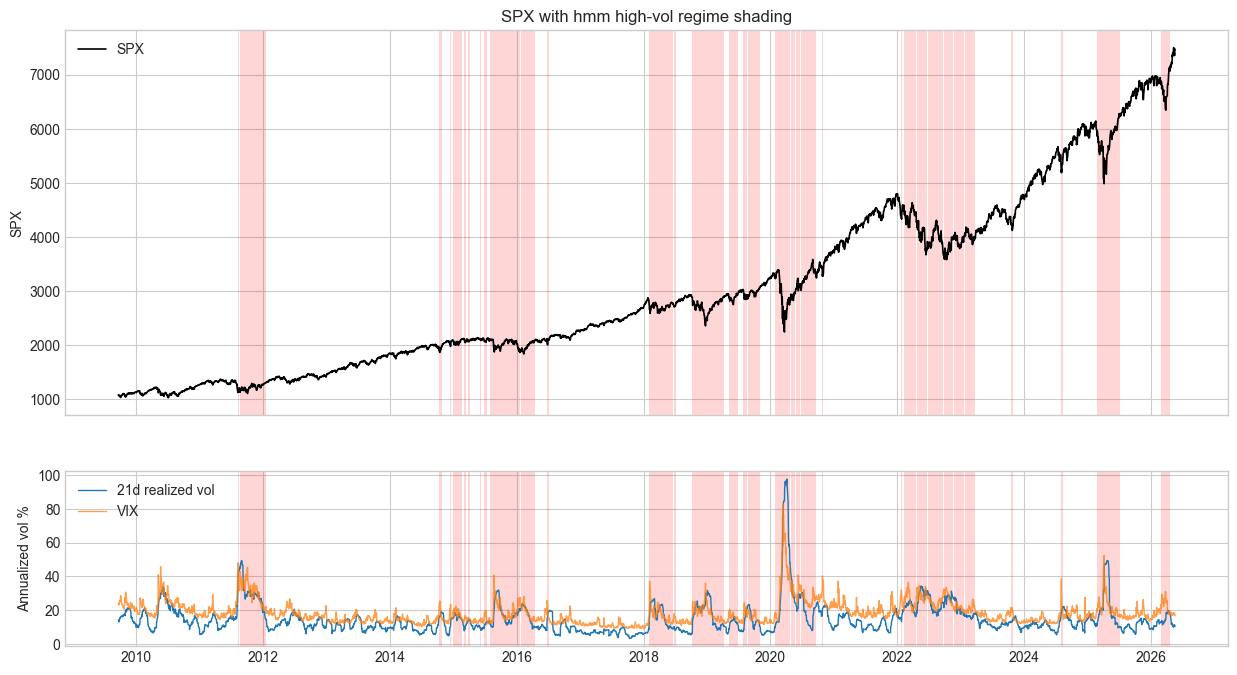

In [56]:
def plot_regime_shading(data: pd.DataFrame, regime: pd.Series, method: str) -> None:
    plot_df = data[["SPX", "RV_21", "VIX"]].join(regime.rename("regime"), how="inner").dropna(subset=["SPX", "regime"])
    fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True, gridspec_kw={"height_ratios": [2.2, 1]})

    axes[0].plot(plot_df.index, plot_df["SPX"], color="black", linewidth=1.2, label="SPX")
    high_vol = plot_df["regime"].eq("high_vol")
    blocks = high_vol.ne(high_vol.shift()).cumsum()
    for _, block in plot_df[high_vol].groupby(blocks[high_vol]):
        axes[0].axvspan(block.index[0], block.index[-1], color="red", alpha=0.16, linewidth=0)
        axes[1].axvspan(block.index[0], block.index[-1], color="red", alpha=0.16, linewidth=0)

    axes[0].set_title(f"SPX with {method} high-vol regime shading")
    axes[0].set_ylabel("SPX")
    axes[0].legend(loc="upper left")

    axes[1].plot(plot_df.index, plot_df["RV_21"], color="tab:blue", linewidth=1.0, label="21d realized vol")
    axes[1].plot(plot_df.index, plot_df["VIX"], color="tab:orange", linewidth=1.0, alpha=0.75, label="VIX")
    axes[1].set_ylabel("Annualized vol %")
    axes[1].legend(loc="upper left")
    plt.show()


for method in ["threshold", "cluster", "hmm"]:
    if method in regimes and regimes[method].notna().any():
        plot_regime_shading(study_df, regimes[method], method)

In [57]:
def choose_method(spreads: pd.DataFrame, regimes: pd.DataFrame) -> pd.DataFrame:
    candidates = spreads.copy()
    coverage = regimes.notna().mean().rename("coverage")
    candidates = candidates.join(coverage, how="left")
    candidates = candidates[candidates["coverage"] >= 0.60].copy()

    if candidates.empty:
        return pd.DataFrame()

    # Favor clear vol/choppiness/trend separation, but penalize noisy flipping.
    rank_inputs = pd.DataFrame(index=candidates.index)
    rank_inputs["rv"] = candidates["rv_spread_high_minus_low"].rank(pct=True)
    rank_inputs["flip"] = candidates["flip_spread_high_minus_low"].rank(pct=True)
    rank_inputs["trend"] = candidates["trend_spread_low_minus_high"].rank(pct=True)
    rank_inputs["stability"] = (-candidates["transition_rate"]).rank(pct=True)
    candidates["practical_score"] = rank_inputs.mean(axis=1)
    return candidates.sort_values("practical_score", ascending=False)


method_ranking = choose_method(spreads, regimes)
recommended_method = method_ranking.index[0] if not method_ranking.empty else "threshold"
method_ranking.style.format(
    {
        "rv_spread_high_minus_low": "{:.1f}",
        "vix_spread_high_minus_low": "{:.1f}",
        "flip_spread_high_minus_low": "{:.1%}",
        "trend_spread_low_minus_high": "{:.1%}",
        "drawdown_spread_high_minus_low": "{:.1%}",
        "transition_rate": "{:.1f}",
        "horizon_22d_spread_low_minus_high": "{:.2%}",
        "coverage": "{:.1%}",
        "practical_score": "{:.2f}",
    }
)

,rv_spread_high_minus_low,vix_spread_high_minus_low,flip_spread_high_minus_low,trend_spread_low_minus_high,drawdown_spread_high_minus_low,transition_rate,horizon_22d_spread_low_minus_high,coverage,practical_score
method,,,,,,,,,
threshold,15.6,11.9,4.4%,7.0%,-11.8%,2.5,-0.49%,100.0%,1.00
cluster,13.8,11.2,1.4%,6.7%,-13.0%,6.0,-0.64%,97.3%,0.67
hmm,9.4,6.3,0.2%,5.8%,-6.3%,11.9,-0.44%,84.7%,0.33


## Recommendation Framework

The final step ranks the available methods by practical usefulness. A good regime classifier should create a clear gap between high-vol and low-vol states, but it should not flip so often that the signal becomes hard to trade or monitor.

The score below rewards volatility separation, choppiness separation, low-vol trend strength, stability, and data coverage. The top-ranked method becomes the notebook's recommended primary regime filter.

In [58]:
from IPython.display import Markdown, display

conclusion = f"""
## Research Conclusion

The evidence should be judged by whether the detected states match the economic story, not by whether a model produces two labels.

- A useful **low-vol / slow-bull** state should have lower `RV_21` and `VIX`, positive 63-day trend, shallower drawdowns, and fewer daily sign flips.
- A useful **high-vol / choppy** state should have higher realized/implied volatility, more sign flips, worse drawdowns, and less stable forward returns.
- The recommended regime definition from this run is **`{recommended_method}`**, because it offers the best practical balance of regime separation, stability, and data coverage in the scoring table above.

For trading or monitoring, start with the recommended method as the primary regime filter. Keep the other two methods as cross-checks: if threshold, clustering, and HMM all agree on high-vol, treat that as a stronger risk-off/choppy signal; if they disagree, size decisions more conservatively.
"""

display(Markdown(conclusion))


## Research Conclusion

The evidence should be judged by whether the detected states match the economic story, not by whether a model produces two labels.

- A useful **low-vol / slow-bull** state should have lower `RV_21` and `VIX`, positive 63-day trend, shallower drawdowns, and fewer daily sign flips.
- A useful **high-vol / choppy** state should have higher realized/implied volatility, more sign flips, worse drawdowns, and less stable forward returns.
- The recommended regime definition from this run is **`threshold`**, because it offers the best practical balance of regime separation, stability, and data coverage in the scoring table above.

For trading or monitoring, start with the recommended method as the primary regime filter. Keep the other two methods as cross-checks: if threshold, clustering, and HMM all agree on high-vol, treat that as a stronger risk-off/choppy signal; if they disagree, size decisions more conservatively.
